In [1]:
import sys

import trimesh
import numpy as np

from hra_amap.registration.organ import Organ
from hra_amap.registration.tissue import TissueBlock
from hra_amap.registration.pipeline import Pipeline
from hra_amap.registration.steps import normalize_rigid
from hra_amap.utils.conversions import to_array
from hra_amap.utils.io import read_yaml
from scripts.constants import ConfigKeys

from copy import deepcopy
from tqdm.auto import tqdm
from pathlib import Path

##### Load a mesh as a point cloud

In [2]:
config = Path("../input-data/millitome/pancreas-female-vu/v1.0/config.yaml")
config_dict = read_yaml(config)
config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.SOURCE] = config.parent / config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.SOURCE]
config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.TARGET] = config.parent / config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.TARGET]

In [3]:
# load source and reference organs
source = Organ(path=config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.SOURCE], target_name = config_dict[ConfigKeys.TARGET_NAME], metadata = config_dict)
target = Organ(path=config_dict[ConfigKeys.INPUT_FILES][ConfigKeys.TARGET], target_name = config_dict[ConfigKeys.TARGET_NAME], metadata = config_dict)

##### Visualize point cloud (before)

In [4]:
# normalize (optional)
output = normalize_rigid(source=deepcopy(source.pointcloud), target=deepcopy(target.pointcloud))
normalized_source_atlas = to_array(output.output['Source'])
normalized_target_atlas = to_array(output.output['Target'])

In [5]:
source_pc = trimesh.PointCloud(normalized_source_atlas, colors=np.tile(np.array([255, 0, 0, 1]), (len(normalized_source_atlas), 1)))
hra_pc = trimesh.PointCloud(normalized_target_atlas, colors=np.tile(np.array([0, 0, 255, 1]), (len(normalized_target_atlas), 1)))
before_scene = trimesh.Scene([source_pc, hra_pc])
# before_scene.export('/Users/bhargavdesai/Desktop/test/before.glb')
before_scene.show()

In [6]:
trimesh.Scene([source_pc]).show()

In [7]:
trimesh.Scene([hra_pc]).show()

##### Register point cloud

In [8]:
# instantiate the registration pipeline
pipeline = Pipeline(name='Base Registration', description='Base Registration', params=config)

In [9]:
# run registration
projections = pipeline.run(source=source, target=target)

[Open3D WARNING] Too few correspondences (35) after mutual filter, fall back to original correspondences.


##### Visualize point cloud (after)

In [10]:
projected_pc = trimesh.PointCloud(projections.registration.vertices, colors=np.tile(np.array([255, 0, 0, 1]), (len(projections.registration.vertices), 1)))
hra_pc = trimesh.PointCloud(target.vertices, colors=np.tile(np.array([0, 0, 255, 1]), (len(target.vertices), 1)))
after_scene = trimesh.Scene([projected_pc, hra_pc])
# after_scene.export('/Users/bhargavdesai/Desktop/AMap/Figures/Figure 1/after.glb')
after_scene.show()

In [11]:
projections.registration.show()

##### Heatmap

In [12]:
from sklearn.preprocessing import minmax_scale

In [21]:
# sampled = projections.registration.simplify_quadric_decimation(10000)

In [13]:
sd = trimesh.proximity.signed_distance(target, projections.registration.vertices)

/Applications/anaconda3/envs/amap3/lib/python3.12/site-packages/trimesh/triangles.py:656: RuntimeWarning: invalid value encountered in divide
  v = (d1[is_ab] / (d1[is_ab] - d3[is_ab])).reshape((-1, 1))


In [14]:
# rescale
sd_scaled = minmax_scale(sd, feature_range=(-1, 1), axis=0, copy=True)

# create colors
cmap = 'jet'
colors = trimesh.visual.interpolate(sd, color_map=cmap)

# rebuild the registered organ
heatmap = trimesh.Trimesh(vertices=np.array(projections.registration.vertices), faces=np.array(projections.registration.faces), vertex_colors=colors)

In [15]:
# heatmap.export('/Users/bhargavdesai/Desktop/AMap/Figures/Figure 1/errormap.glb')
heatmap.show()

##### Histogram

In [16]:
import seaborn as sns

In [17]:
sns.set_style('darkgrid')
sns.set_theme('paper')

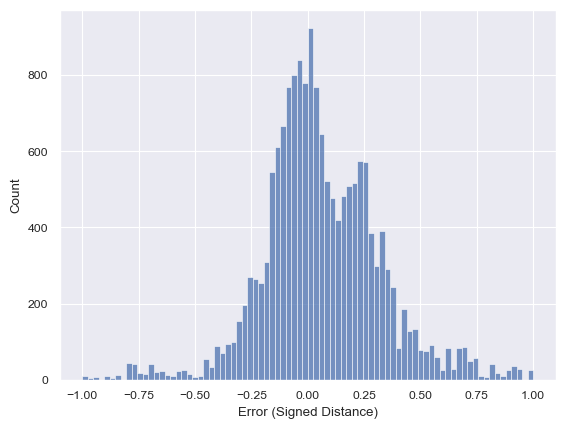

In [18]:
hist = sns.histplot(data=sd_scaled).set_xlabel('Error (Signed Distance)')
fig = hist.get_figure()
# fig.savefig("/Users/bhargavdesai/Desktop/AMap/Figures/Figure 1/hist.png") 